# Lab: Model Inversion (Extracting the "Ghost" in the Machine)


We will use the MNIST model and then "interrogate" it by saying: *"I don't know what a '5' looks like. You tell me what the perfect '5' looks like by shifting these random pixels around."*

### Learning Objective

To demonstrate that machine learning models "remember" the features of their training data, and that these features can be reconstructed by an attacker with access to the model's confidence scores.

---

## 1. The Setup

We will use the same MNIST CNN model from the FGSM lab. Ensure that your `model` object is in `eval()` mode.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Set device (CPU is perfectly fine for this!)
device = torch.device("cpu")

# Load MNIST test set
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, download=True,
                   transform=transforms.Compose([transforms.ToTensor(),])),
    batch_size=1, shuffle=True)

---

## 2. The Target Model

We need a model to attack. For a quick demo, we'll define a simple CNN and train it for **one epoch**. This may take 5 - 6 minutes.

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc2(self.fc1(x))
        return F.log_softmax(x, dim=1)

# Initialize and train briefly
model = Net().to(device)
optimizer = optim.Adadelta(model.parameters(), lr=1.0)
print("Training model for 1 epoch...")
model.train()
for data, target in test_loader: # Using test_loader just for a quick subset training
    optimizer.zero_grad()
    output = model(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()
model.eval()
print("Model ready!")

Training model for 1 epoch...
Model ready!


In [ ]:
# Ensure model is ready
#model.eval()
#device = torch.device("cpu")

---

## 2. The Attack: Gradient Ascent on Pixels

In normal training, we keep the data fixed and update the weights. In Model Inversion, we **freeze the weights** and **update the pixels**.

We want to find an image $x$ that maximizes the probability of a `target_class`.

In [ ]:
def invert_class(model, target_class, iterations=50, lr=0.1):
    # 1. Start with pure random noise (representing a blank slate)
    input_noise = torch.randn(1, 1, 28, 28, device=device, requires_grad=True)

    # We use a simple optimizer to handle the pixel updates
    optimizer = torch.optim.Adam([input_noise], lr=lr)

    history = []

    for i in range(iterations):
        optimizer.zero_grad()

        # 2. Ask the model what it thinks of this noise
        output = model(input_noise)

        # 3. Calculate "Loss"
        # We want to MINIMIZE the distance to the target class
        # (Essentially Maximizing the confidence for that class)
        loss = F.nll_loss(output, torch.tensor([target_class]))

        loss.backward()
        optimizer.step()

        # Keep pixels in valid [0, 1] range
        input_noise.data.clamp_(0, 1)

        # Save progress every 5 steps for the "Aha!" moment
        if i % 5 == 0 or i == iterations - 1:
            history.append(input_noise.detach().cpu().clone().squeeze())

    return history


In [ ]:

# Choose a digit to reconstruct
target = 8
print(f"Reconstructing the model's memory of digit: {target}...")
reconstructed_images = invert_class(model, target)

Reconstructing the model's memory of digit: 8...


---

## 3. Visualization: Watching the "Ghost" Appear

We will plot the evolution of the image from random static to a recognizable digit.

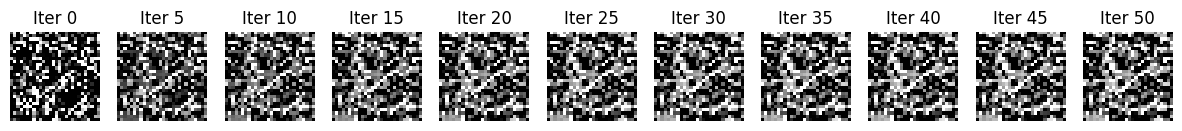

In [ ]:
plt.figure(figsize=(15, 5))
for i, img in enumerate(reconstructed_images):
    plt.subplot(1, len(reconstructed_images), i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Iter {i*5}")
    plt.axis('off')
plt.show()

---

## 4. Verification

Now, we ask the model what it thinks of the image it just "created."

In [ ]:
final_img = reconstructed_images[-1].unsqueeze(0).unsqueeze(0)
output = model(final_img)
confidence = torch.exp(output.max()) * 100
pred = output.argmax().item()

print(f"Final Prediction: {pred}")
print(f"Model Confidence: {confidence:.2f}%")

Final Prediction: 8
Model Confidence: 100.00%


---

## Lab Discussion Questions

### 1. The Visual Quality

**Question:** The reconstructed digit looks "ghostly" or like a blurry average. Why doesn't it look like a crisp, perfect handwritten digit?

* **Answer:** The model didn't memorize one specific "5" from the dataset; it learned the *features* that are common to all 5s. You are seeing the "platonic ideal" of a 5 according to this specific model's weights.

### 2. Privacy Implications

**Question:** If this were a facial recognition model for a high-security building, what could an attacker do with this technique?

* **Answer:** An attacker could reconstruct the faces of the people allowed in the building (the training set), even if they never had access to the original photos. This is a massive **Privacy Breach**.

### 3. The Comparison

Use the table below to summarize the three labs you have completed:

| Attack Type | Phase | The "Weapon" | The Result |
| --- | --- | --- | --- |
| **Data Poisoning** | Training | Malicious Data | A "Backdoor" trigger |
| **Adversarial Input** | Inference | Calculated Noise | Misclassification |
| **Model Inversion** | Post-Training | Confidence Scores | Reconstructed Training Data |

---

### Instructor Tips for Colab:

* **Initialization:** If the reconstruction looks like a blob, try running it again. Since it starts with `randn`, the initial "seed" matters.
* **The Target:** Digits like `0`, `3`, and `7` usually reconstruct very clearly. Digits like `1` or `8` can sometimes be messy.
* **Scaling:** If you used a very simple model with only one epoch of training, the inversion will be easier but the image will be noisier. A more complex model usually produces "cleaner" (and thus more dangerous) reconstructions.